Importing Libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import *#


Take Input


In [ ]:
f1_inp = input("Enter f1(x): ")
f2_inp = input("Enter f2(x): ")


Enter f1(x): x
Enter f2(x): x**3


Convert input string into mathematical function


In [ ]:
def make_function(expr):
    def f(x):
        try:
            return eval(expr)
        except:
            return np.nan
    return f

In [ ]:
f1 = make_function(f1_inp)
f2 = make_function(f2_inp)
print(f1(10))
print(f2(20))

10
8000


Range

In [ ]:
x = np.linspace(0, 100, 1000)
y1 = np.array([f1(val) for val in x])
y2 = np.array([f2(val) for val in x])
print(y1)
print(y2)

[  0.           0.1001001    0.2002002    0.3003003    0.4004004
   0.5005005    0.6006006    0.7007007    0.8008008    0.9009009
   1.001001     1.1011011    1.2012012    1.3013013    1.4014014
   1.5015015    1.6016016    1.7017017    1.8018018    1.9019019
   2.002002     2.1021021    2.2022022    2.3023023    2.4024024
   2.5025025    2.6026026    2.7027027    2.8028028    2.9029029
   3.003003     3.1031031    3.2032032    3.3033033    3.4034034
   3.5035035    3.6036036    3.7037037    3.8038038    3.9039039
   4.004004     4.1041041    4.2042042    4.3043043    4.4044044
   4.5045045    4.6046046    4.7047047    4.8048048    4.9049049
   5.00500501   5.10510511   5.20520521   5.30530531   5.40540541
   5.50550551   5.60560561   5.70570571   5.80580581   5.90590591
   6.00600601   6.10610611   6.20620621   6.30630631   6.40640641
   6.50650651   6.60660661   6.70670671   6.80680681   6.90690691
   7.00700701   7.10710711   7.20720721   7.30730731   7.40740741
   7.50750751   7.60

Plot Individual Function


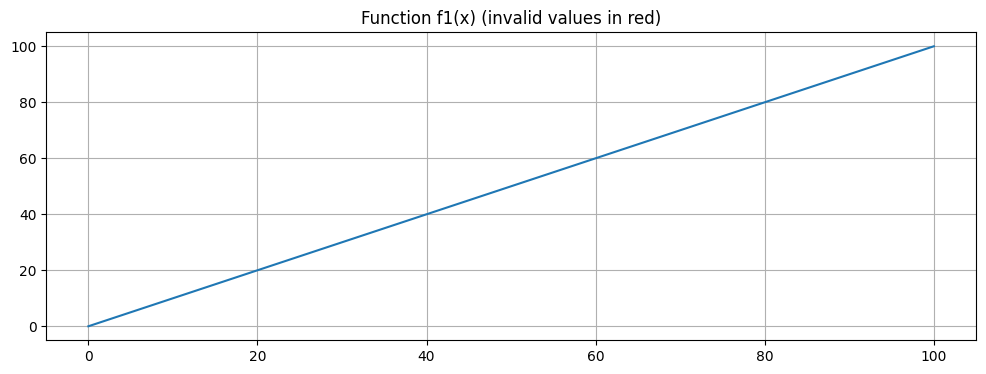

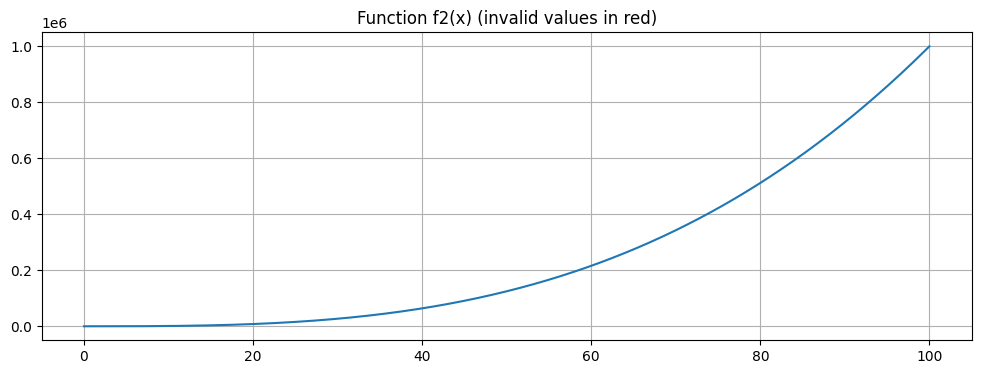

In [ ]:
def plot_input(arr, title):
    plt.figure(figsize=(12,4))
    plt.plot(x, arr)
    plt.fill_between(x, arr, where=np.isnan(arr), color="red", alpha=0.3)
    plt.title(title + " (invalid values in red)")
    plt.grid(True)
    plt.show()

plot_input(y1, "Function f1(x)")
plot_input(y2, "Function f2(x)")

Mathematical Operation

Boundary Conditions:-






*   Power Boundary:-
Cases where:
 1. base y1 <= 0, negative or zero base with fractional exponent can lead to complex results.
 2. exponent y2 > 10 is restricted to avoid overflow explosion (value would exceed numeric range).
 3. If either invalid, return NaN.

*  Modulus boundary:
Modulus by zero is undefined: y % 0 produces error.
When y2 == 0 set NaN.


*   Logarithm boundary:-
log(a/b) is only defined if both a and b are positive.
Here we use log((y1+1)/(y2+1)):
 1 is added to avoid direct log(0).
 If numerator or denominator becomes <= 0, log output becomes invalid.
*   Square root boundary:-
sqrt of negative is invalid for real output.
We force non-negativity by taking absolute difference.
sqrt(|y1 - y2|)


*   Exponential boundary:
exp grows extremely fast.
exp(> 50) is near overflow of floating range (e ~ 2.7^x).
So if exponent (y1 - y2) > 50, return NaN instead of overflow.

















In [ ]:
add = y1 + y2
sub = y1 - y2
mul = y1 * y2
div = np.array([np.nan if y2[i] == 0 else y1[i] / y2[i] for i in range(len(x))])#Division is undefined when denominator=0, So if y2[i] == 0, return NaN instead of crashing or returning infinity.
pow = np.array([np.nan if (y1[i] <= 0 or y2[i] > 10) else y1[i]**y2[i] for i in range(len(x))])
mod = np.array([np.nan if y2[i] == 0 else y1[i] % y2[i] for i in range(len(x))])
log = np.array([np.nan if ((y1[i] + 1) <= 0 or (y2[i] + 1) <= 0) else np.log((y1[i]+1)/(y2[i]+1)) for i in range(len(x))])
sqrt = np.sqrt(np.abs(y1 - y2))
exp = np.array([np.nan if (y1[i] - y2[i]) > 50 else np.exp(y1[i] - y2[i]) for i in range(len(x))])

DIFFERENTIATION & INTEGRATION


In [ ]:
dy1 = np.gradient(y1, x)
dy2 = np.gradient(y2, x)

area = np.trapz(np.abs(y1 - y2), x)
print("\nRaw Area between curves =", area)


Raw Area between curves = 24995025.545253746


/tmp/ipython-input-2008430251.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(np.abs(y1 - y2), x)


BOUNDARY CAUSES


In [ ]:
def find_causes():
    causes = {}
    causes["division_zero"] = x[(y2 == 0)]
    causes["power_invalid"] = x[(y1 <= 0) | (y2 > 10)]
    causes["log_negative"] = x[((y1+1) <= 0) | ((y2+1) <= 0)]
    causes["exp_overflow"] = x[(y1 - y2) > 50]
    causes["mod_zero"] = x[(y2 == 0)]
    causes["dy1_nan"] = x[np.isnan(dy1)]
    causes["dy2_nan"] = x[np.isnan(dy2)]
    return causes

causes = find_causes()

In [ ]:

print("Causes of invalidity")
for k, v in causes.items():
    if len(v) > 0:
        print(k, "at x:", v[:10], "..." if len(v) > 10 else "")
    else:
        print(k, ": none")


Causes of invalidity
division_zero at x: [0.] 
power_invalid at x: [0.        2.2022022 2.3023023 2.4024024 2.5025025 2.6026026 2.7027027
 2.8028028 2.9029029 3.003003 ] ...
log_negative : none
exp_overflow : none
mod_zero at x: [0.] 
dy1_nan : none
dy2_nan : none


Cleaning:-


replaces infinite results (+infinity

or -infinity) with NaN.


replaces unrealistically large numbers (overflow) with NaN



In [ ]:
def clean(arr):
    arr = np.where(np.isinf(arr), np.nan, arr)
    arr = np.where(np.abs(arr) > 1e10, np.nan, arr)
    return arr


In [ ]:
add_clean = clean(add)
sub_clean = clean(sub)
mul_clean = clean(mul)
div_clean = clean(div)
pow_result = clean(pow)
mod_result = clean(mod)
log_ratio = clean(log)
root_diff = clean(sqrt)
exp_mix = clean(exp)
dy1_clean = clean(dy1)
dy2_clean = clean(dy2)
print("Addition:-",add_clean)
print("\n Differentiation of f1",dy1_clean)



Addition:- [0.00000000e+00 1.01103106e-01 2.08224248e-01 3.27381463e-01
 4.64592785e-01 6.25876252e-01 8.17249899e-01 1.04473176e+00
 1.31433988e+00 1.63209228e+00 2.00400701e+00 2.43610210e+00
 2.93439559e+00 3.50490551e+00 4.15364989e+00 4.88664679e+00
 5.70991422e+00 6.62947023e+00 7.65133285e+00 8.78152012e+00
 1.00260501e+01 1.13909408e+01 1.28822102e+01 1.45058764e+01
 1.62679575e+01 1.81744714e+01 2.02314362e+01 2.24448700e+01
 2.48207907e+01 2.73652165e+01 3.00841653e+01 3.29836551e+01
 3.60697041e+01 3.93483303e+01 4.28255516e+01 4.65073862e+01
 5.03998520e+01 5.45089671e+01 5.88407496e+01 6.34012174e+01
 6.81963886e+01 7.32322813e+01 7.85149135e+01 8.40503031e+01
 8.98444684e+01 9.59034272e+01 1.02233198e+02 1.08839798e+02
 1.15729245e+02 1.22907559e+02 1.30380756e+02 1.38154855e+02
 1.46235874e+02 1.54629831e+02 1.63342744e+02 1.72380630e+02
 1.81749509e+02 1.91455398e+02 2.01504314e+02 2.11902277e+02
 2.22655304e+02 2.33769413e+02 2.45250623e+02 2.57104950e+02
 2.69338414e+

Plot each operation separately

In [ ]:
def plot_op(arr, title, cause_key):
    plt.figure(figsize=(12,4))
    plt.plot(x, arr)
    plt.fill_between(x, arr, where=np.isnan(arr), color="red", alpha=0.3)
    if cause_key in causes:
        for xp in causes[cause_key]:
            plt.axvline(x=xp, color='black', linestyle='--', linewidth=0.4)
    plt.title(title)
    plt.grid(True)
    plt.show()

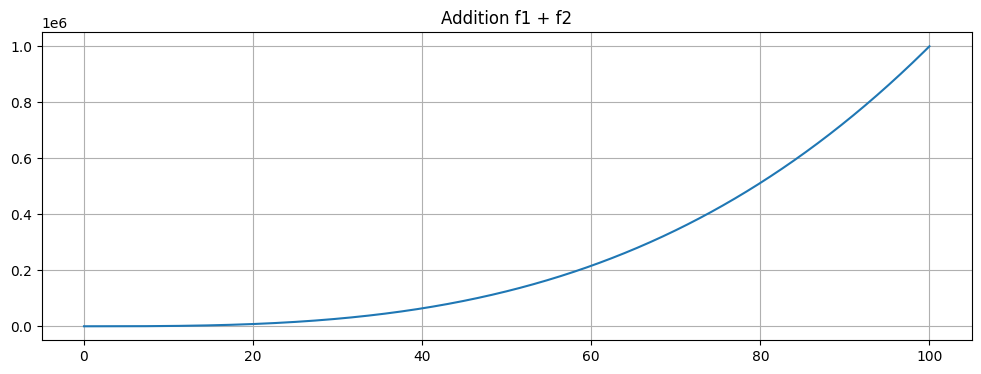

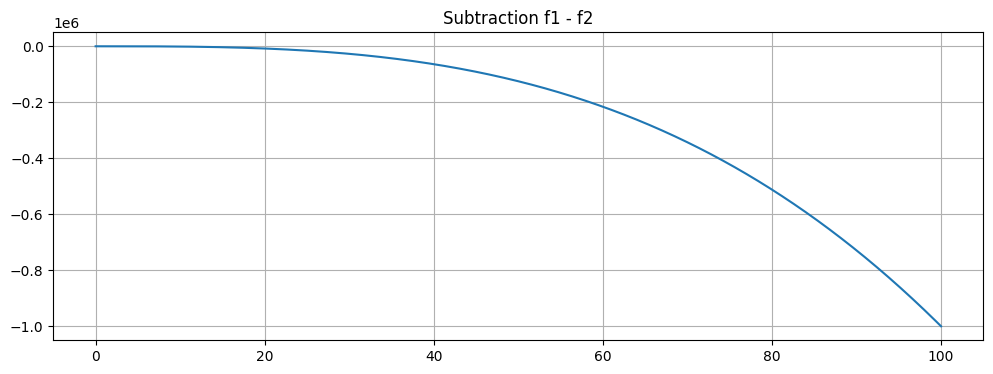

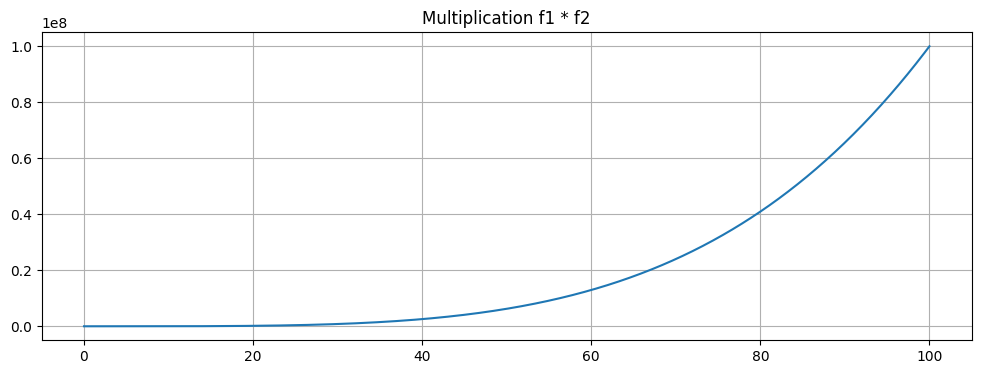

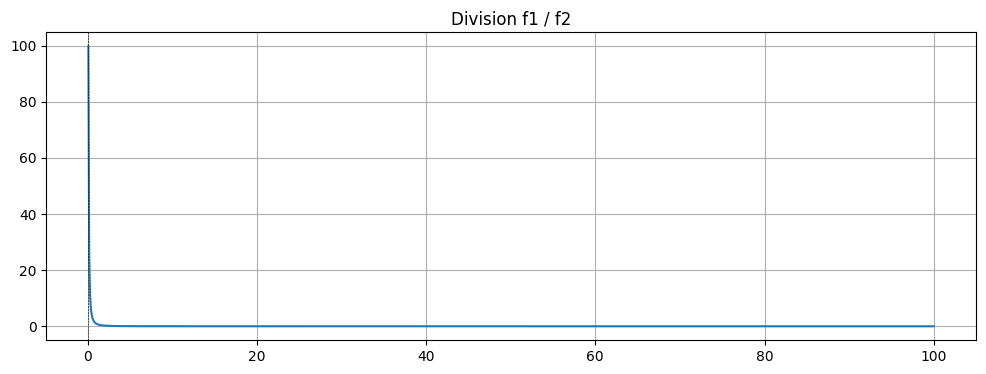

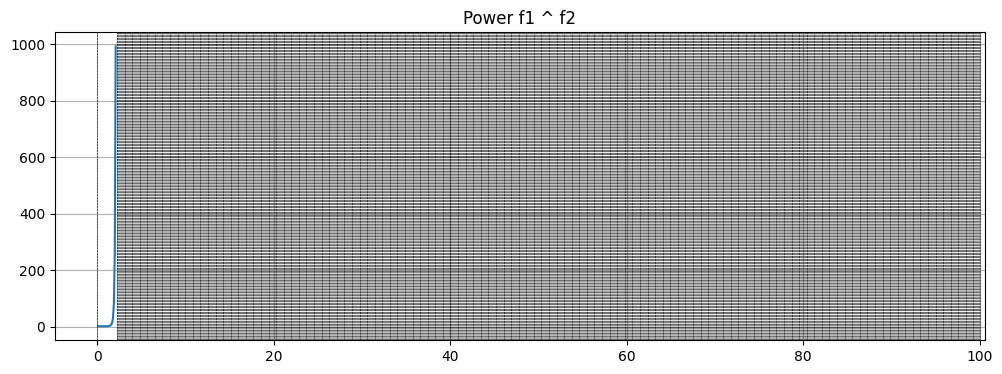

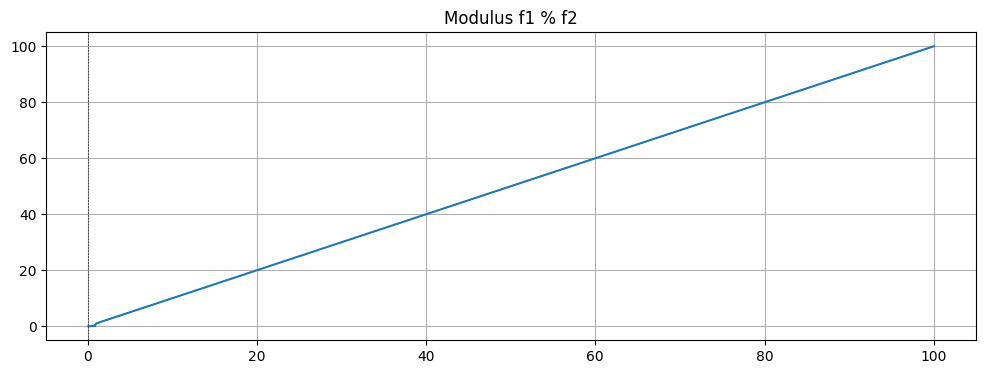

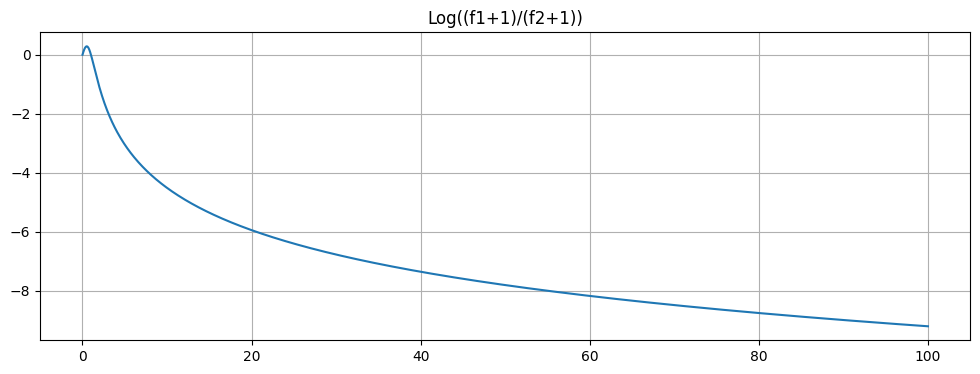

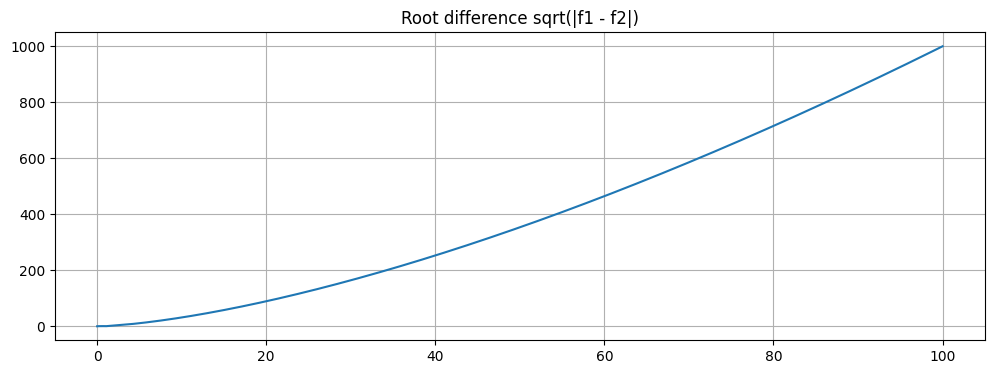

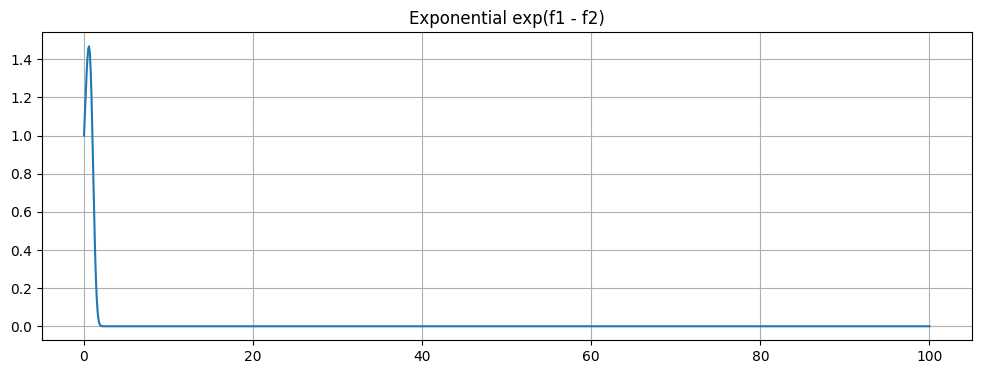

In [ ]:
plot_op(add_clean, "Addition f1 + f2", None)
plot_op(sub_clean, "Subtraction f1 - f2", None)
plot_op(mul_clean, "Multiplication f1 * f2", None)
plot_op(div_clean, "Division f1 / f2", "division_zero")
plot_op(pow_result, "Power f1 ^ f2", "power_invalid")
plot_op(mod_result, "Modulus f1 % f2", "mod_zero")
plot_op(log_ratio, "Log((f1+1)/(f2+1))", "log_negative")
plot_op(root_diff, "Root difference sqrt(|f1 - f2|)", None)
plot_op(exp_mix, "Exponential exp(f1 - f2)", "exp_overflow")

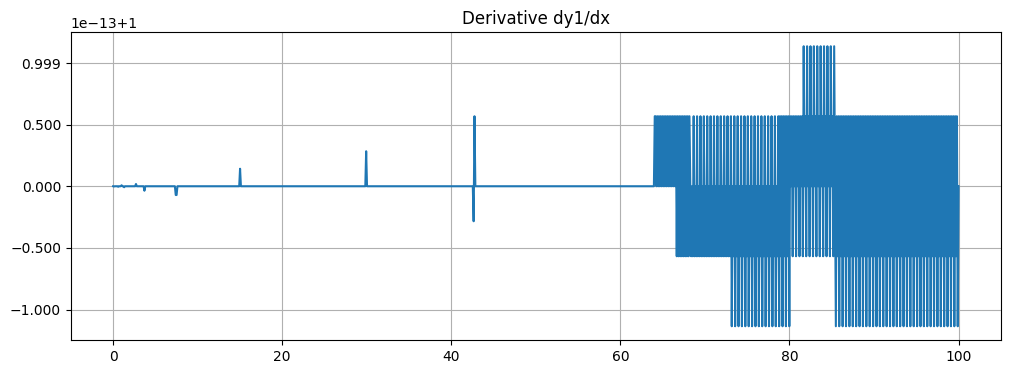

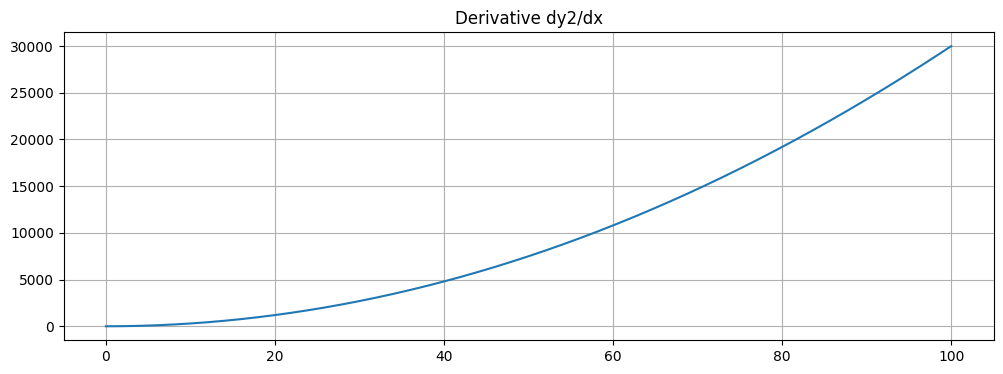

In [ ]:
plot_op(dy1_clean, "Derivative dy1/dx", "dy1_nan")
plot_op(dy2_clean, "Derivative dy2/dx", "dy2_nan")

In [ ]:
area_clean = np.trapz(np.abs(y1 - y2), x)
print("\nCleaned Area between curves =", area_clean)


Cleaned Area between curves = 24995025.545253746


/tmp/ipython-input-1967295039.py:1: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_clean = np.trapz(np.abs(y1 - y2), x)


### Report
 Function Calculator with Boundary Handling
* **Objective**





The goal of this assignment was to build a calculator that takes two mathematical functions as input, evaluates them over a fixed range (0 to 100), performs element-wise operations between them, and visualizes the results. The system also had to correctly handle mathematical boundary cases and report them clearly.

* **What I Did**

Took two user-defined functions as input in standard mathematical form (for example,
𝑥
2
+
sin
⁡
(
𝑥
)
x
2
+sin(x)).

Evaluated both functions over a continuous range from 0 to 100.

Performed element-wise operations such as addition, subtraction, multiplication, division, power, logarithmic ratio, square root difference, and exponential.

Computed numerical derivatives of both input functions.

Calculated the area between the two curves using numerical integration.

Plotted each function and each operation separately so that results are easy to understand.

Highlighted invalid regions on graphs instead of hiding them.


* **Boundary Conditions and How I Handled Them**

Mathematical functions often fail at certain values. These cases were explicitly handled:

Division by zero: Division was marked invalid wherever the denominator became zero.

Logarithm issues: Logarithms were allowed only when inputs were positive.

Power operation issues: Invalid cases such as negative bases or very large exponents were restricted.

Square root issues: Square root of negative values was avoided by using absolute differences.

Exponential overflow: Extremely large exponential values were treated as invalid.

Numerical overflow: Very large values were removed to prevent graph distortion.

Instead of crashing or giving misleading results, all such cases were marked as invalid.

* **How Errors Were Reported**
Invalid values were replaced with undefined values.

Exact positions where errors occurred were printed.

Invalid regions were clearly shaded in the plots.

This made it easy to see where the math breaks and why.

* **Visualization**

Input functions were plotted individually.

Each mathematical operation had its own separate graph.

Derivatives were plotted separately.

Invalid regions were visually marked.

This ensured clarity and avoided confusion caused by overlapping plots.

* **Key Observations**

Some operations look correct but hide small effects (for example,
𝑥
2
+
sin
⁡
(
𝑥
)
x
2
+sin(x) looks like
𝑥
2
x
2
 because
sin
⁡
(
𝑥
)
sin(x) is very small in comparison).

Large-scale functions can visually dominate smaller ones.

Proper boundary handling is essential to avoid misleading plots.

* ***Conclusion***
This assignment successfully demonstrates how to:

Evaluate mathematical functions numerically

Handle real-world mathematical edge cases

Perform differentiation and integration

Visualize results clearly and safely

The final calculator is robust, informative, and easy to interpret, even when mathematical operations become undefined.